<a href="https://colab.research.google.com/github/dprobity/machinelearning/blob/main/Updated_of_CS583HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imports**

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns


# This part generates the arithmetic and key sequence data


In [2]:
import pandas as pd
import random

# Generate Arithmetic Operations sequences with two patterns
arithmetic_sequences = []

for i in range(100):
    pattern_type = i % 2  # Define 2 types of patterns
    sequence = []
    if pattern_type == 0:  # Alternating differences (e.g., +5, -3, +5, -3)
        start = random.randint(500, 1000)
        diff1, diff2 = random.randint(1, 10), random.randint(-10, -1)
        sequence = [start]
        while len(sequence) < 100:
            next_value = sequence[-1] + (diff1 if len(sequence) % 2 == 1 else diff2)
            if next_value <= 0:
                next_value = random.randint(1, 100)  # Reset to positive if needed
            sequence.append(next_value)
    elif pattern_type == 1:  # Repeating fixed difference (e.g., +7, +7, +7, ...)
        start = random.randint(500, 1000)
        diff = random.randint(1, 20)
        sequence = [start]
        for _ in range(99):
            next_value = sequence[-1] + diff
            if next_value <= 0:
                next_value = random.randint(1, 100)  # Reset to positive if needed
            sequence.append(next_value)
    arithmetic_sequences.append(sequence)

# Generate Key Sequences with two patterns
keyboard_keys = ['Q', 'W', 'E', 'R', 'T', 'Y']
key_sequences = []

for i in range(100):
    pattern_type = i % 2  # Define 2 types of patterns
    sequence = []
    if pattern_type == 0:  # Alternating pattern
        sequence = [keyboard_keys[j % len(keyboard_keys)] for j in range(100)]
    elif pattern_type == 1:  # Gradual shifts
        start_index = random.randint(0, len(keyboard_keys) - 1)
        sequence = [keyboard_keys[(start_index + j) % len(keyboard_keys)] for j in range(100)]
    key_sequences.append(sequence)

# Create DataFrames
arithmetic_df = pd.DataFrame(arithmetic_sequences).add_prefix("Arithmetic_")
key_df = pd.DataFrame(key_sequences).add_prefix("Key_Sequences_")

# Save to CSV
arithmetic_df.to_csv("Patterned_Arithmetic_Sequences.csv", index=False)
key_df.to_csv("Patterned_Key_Sequences.csv", index=False)

print("Datasets saved as 'Arithmetic_Sequences.csv' and 'Key_Sequences.csv'.")

Datasets saved as 'Arithmetic_Sequences.csv' and 'Key_Sequences.csv'.


# It makes sense to inspect the generated raw data before preprocessing it for the network


In [4]:
arith_df = pd.read_csv("Patterned_Arithmetic_Sequences.csv")
keys_df = pd.read_csv("Patterned_Key_Sequences.csv")

print("Arithmetic sample:")
display(arith_df.head())
print("Keys sample:")
display(keys_df.head())


Arithmetic sample:


,Arithmetic_0,Arithmetic_1,Arithmetic_2,Arithmetic_3,Arithmetic_4,Arithmetic_5,Arithmetic_6,Arithmetic_7,Arithmetic_8,Arithmetic_9,...,Arithmetic_90,Arithmetic_91,Arithmetic_92,Arithmetic_93,Arithmetic_94,Arithmetic_95,Arithmetic_96,Arithmetic_97,Arithmetic_98,Arithmetic_99
0,646,650,642,646,638,642,634,638,630,634,...,466,470,462,466,458,462,454,458,450,454
1,603,616,629,642,655,668,681,694,707,720,...,1773,1786,1799,1812,1825,1838,1851,1864,1877,1890
2,636,644,637,645,638,646,639,647,640,648,...,681,689,682,690,683,691,684,692,685,693
3,663,669,675,681,687,693,699,705,711,717,...,1203,1209,1215,1221,1227,1233,1239,1245,1251,1257
4,897,898,890,891,883,884,876,877,869,870,...,582,583,575,576,568,569,561,562,554,555


Keys sample:


,Key_Sequences_0,Key_Sequences_1,Key_Sequences_2,Key_Sequences_3,Key_Sequences_4,Key_Sequences_5,Key_Sequences_6,Key_Sequences_7,Key_Sequences_8,Key_Sequences_9,...,Key_Sequences_90,Key_Sequences_91,Key_Sequences_92,Key_Sequences_93,Key_Sequences_94,Key_Sequences_95,Key_Sequences_96,Key_Sequences_97,Key_Sequences_98,Key_Sequences_99
0,Q,W,E,R,T,Y,Q,W,E,R,...,Q,W,E,R,T,Y,Q,W,E,R
1,E,R,T,Y,Q,W,E,R,T,Y,...,E,R,T,Y,Q,W,E,R,T,Y
2,Q,W,E,R,T,Y,Q,W,E,R,...,Q,W,E,R,T,Y,Q,W,E,R
3,Q,W,E,R,T,Y,Q,W,E,R,...,Q,W,E,R,T,Y,Q,W,E,R
4,Q,W,E,R,T,Y,Q,W,E,R,...,Q,W,E,R,T,Y,Q,W,E,R


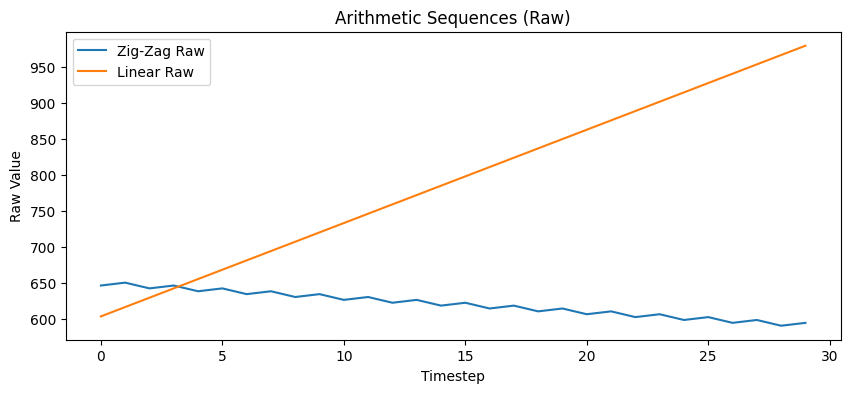

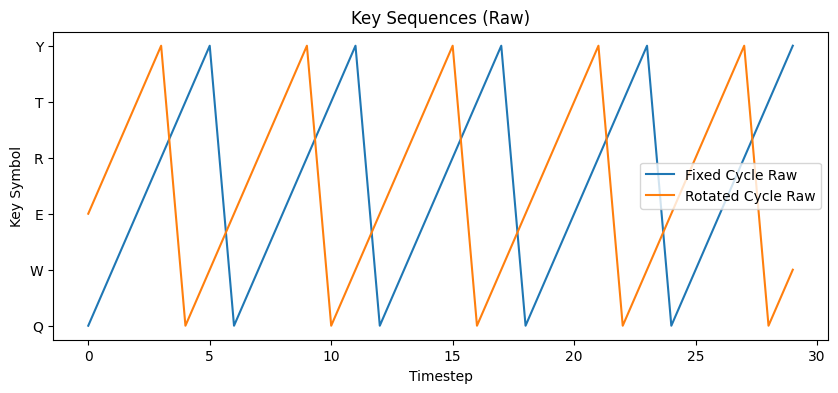

In [9]:
# Arithmetic (Raw)
plt.figure(figsize=(10,4))
plt.plot(arith_df.iloc[0].values[:30], label="Zig-Zag Raw")
plt.plot(arith_df.iloc[1].values[:30], label="Linear Raw")
plt.xlabel("Timestep")
plt.ylabel("Raw Value")
plt.title("Arithmetic Sequences (Raw)")
plt.legend()
plt.show()

# Keys (Raw)
plt.figure(figsize=(10,4))
plt.plot(keys_df.iloc[0].values[:30], label="Fixed Cycle Raw")
plt.plot(keys_df.iloc[1].values[:30], label="Rotated Cycle Raw")
plt.xlabel("Timestep")
plt.ylabel("Key Symbol")
plt.title("Key Sequences (Raw)")
plt.legend()
plt.show()


#To make the code easier to read, I have made it modular.
# I defined functions for the different components, and the final cell
# calls these functions to run the training and visualization.**

# Error handling is included within each function block to help trace
# the origin of any issues in the execution pipeline.


In [11]:
def load_datasets(arith_path="Patterned_Arithmetic_Sequences.csv",
                  key_path="Patterned_Key_Sequences.csv"):
    try:
        arith = pd.read_csv(arith_path)
        keys = pd.read_csv(key_path)
        print("Datasets loaded successfully.")
        return arith, keys
    except Exception as e:
        print("Error loading datasets:", e)
        raise


In [12]:
def preprocess_arithmetic(arith_df, window=10):
    try:
        scaler = MinMaxScaler()
        arith_scaled = scaler.fit_transform(arith_df)

        X, y = [], []
        for seq in arith_scaled:
            for i in range(len(seq) - window):
                X.append(seq[i:i+window])
                y.append(seq[i+window])
        X = np.array(X).reshape(-1, window, 1)
        y = np.array(y)
        print("Arithmetic preprocessing complete.")
        return X, y, scaler
    except Exception as e:
        print("Error in arithmetic preprocessing:", e)
        raise


def preprocess_keys(keys_df, window=10):
    try:
        encoder = LabelEncoder()
        keys_encoded = keys_df.apply(encoder.fit_transform)

        X, y = [], []
        for seq in keys_encoded.values:
            for i in range(len(seq) - window):
                X.append(seq[i:i+window])
                y.append(seq[i+window])
        X = np.array(X).reshape(-1, window, 1)
        y = to_categorical(y, num_classes=len(encoder.classes_))
        print("Key preprocessing complete.")
        return X, y, encoder
    except Exception as e:
        print("Error in key preprocessing:", e)
        raise


In [17]:
def build_arithmetic_model(input_shape):
    try:
        model = Sequential([
            SimpleRNN(50, activation='relu', input_shape=input_shape),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        print("Arithmetic model built.")
        return model
    except Exception as e:
        print("Error building arithmetic model:", e)
        raise


def build_key_model(input_shape, num_classes):
    try:
        model = Sequential([
            SimpleRNN(50, activation='relu', input_shape=input_shape),
            Dense(num_classes, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        print("Key model built.")
        return model
    except Exception as e:
        print("Error building key model:", e)
        raise


In [19]:
def train_model(model, X_train, y_train, epochs=20, batch_size=64, val_split=0.1):
    try:
        history = model.fit(X_train, y_train,
                            validation_split=val_split,
                            epochs=epochs,
                            batch_size=batch_size,
                            verbose=1)
        print("Training complete.")
        return history
    except Exception as e:
        print("Error during training:", e)
        raise


In [20]:
def plot_loss(history, title="Training vs Validation Loss"):
    try:
        plt.plot(history.history['loss'], label='Train Loss')
        if 'val_loss' in history.history:
            plt.plot(history.history['val_loss'], label='Val Loss')
        plt.title(title)
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()
    except Exception as e:
        print("Error plotting loss:", e)
        raise


In [21]:
def evaluate_model(model, X_test, y_test, task="Arithmetic"):
    try:
        results = model.evaluate(X_test, y_test, verbose=0)
        print(f"{task} Test Results:", results)
        return results
    except Exception as e:
        print("Error during evaluation:", e)
        raise


# Here, we call the function blocks to perform data loading, preprocessing,
# the train–test split, model building, training, and the required visualizations.

# See Loss vs Epoch for Training and Validation plot below

Datasets loaded successfully.
Arithmetic preprocessing complete.
Key preprocessing complete.
Arithmetic model built.
Key model built.
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0437 - val_loss: 1.0004e-05
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.1549e-06 - val_loss: 4.7489e-06
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3427e-06 - val_loss: 5.8738e-06
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.5603e-06 - val_loss: 7.2047e-06
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.6448e-06 - val_loss: 1.1875e-05
Epoch 6/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.7607e-06 - val_loss: 4.2880e-06
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.2890e-06 - val_loss: 4.3031e-06
Epoch 8/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.4867e-06 - val_loss: 3.8554e-06
Epoch 9/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.3291e-06 - val_loss: 3.8845e-06
Epoch 10/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.6288e-06 - val_loss: 3.7907e-06
Epoch 11/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.4976e-06 - 

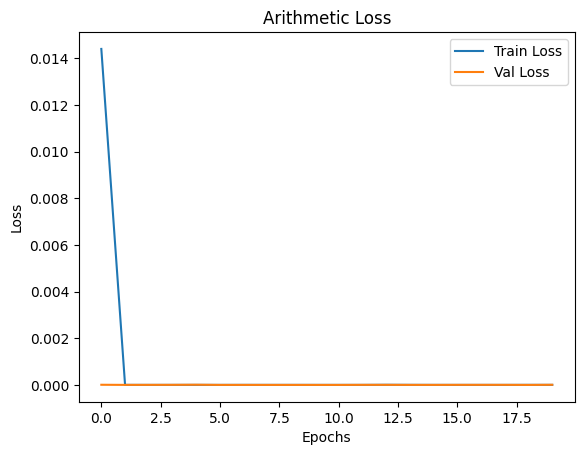

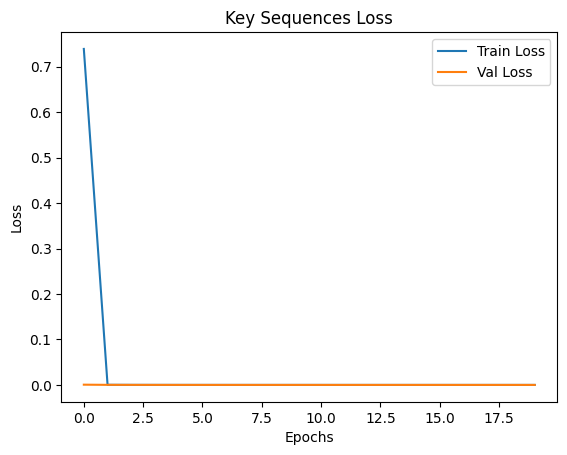

Arithmetic Test Results: 9.473268619331066e-06
Keys Test Results: [2.2459664705820614e-06, 1.0]


[2.2459664705820614e-06, 1.0]

In [22]:
# Load data
arith_df, keys_df = load_datasets()

# Preprocess
Xa, ya, scaler = preprocess_arithmetic(arith_df)
Xk, yk, encoder = preprocess_keys(keys_df)

# Train/test split
Xa_train, Xa_test, ya_train, ya_test = train_test_split(Xa, ya, test_size=0.2)
Xk_train, Xk_test, yk_train, yk_test = train_test_split(Xk, yk, test_size=0.2)

# Build models
arith_model = build_arithmetic_model((Xa_train.shape[1], 1))
key_model = build_key_model((Xk_train.shape[1], 1), len(encoder.classes_))

# Train
hist_arith = train_model(arith_model, Xa_train, ya_train)
hist_keys = train_model(key_model, Xk_train, yk_train)

# Visualize
plot_loss(hist_arith, "Arithmetic Loss")
plot_loss(hist_keys, "Key Sequences Loss")

# Evaluate
evaluate_model(arith_model, Xa_test, ya_test, "Arithmetic")
evaluate_model(key_model, Xk_test, yk_test, "Keys")


# Evaluation - Prediction Vs Actual Plot

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


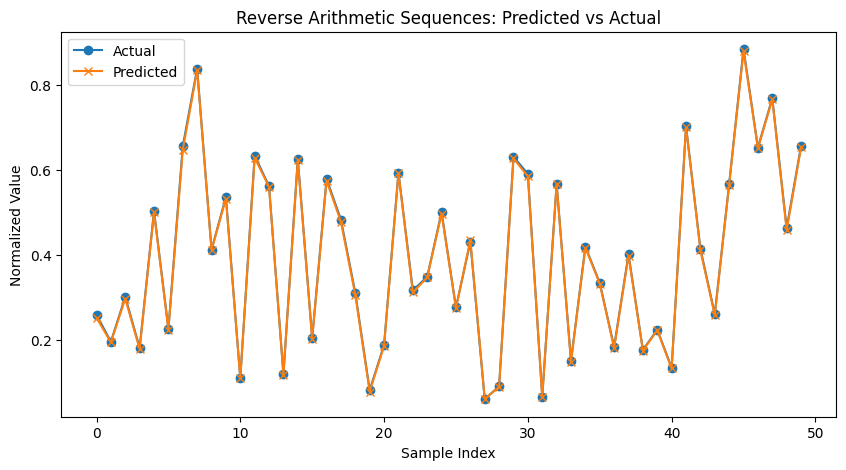

Sample 0: Actual = 0.259, Predicted = 0.252
Sample 1: Actual = 0.196, Predicted = 0.195
Sample 2: Actual = 0.302, Predicted = 0.298
Sample 3: Actual = 0.182, Predicted = 0.179
Sample 4: Actual = 0.504, Predicted = 0.501


In [24]:
# Predict on test set
y_pred_arith = arith_model.predict(Xa_test)

# Plot predicted vs actual
plt.figure(figsize=(10,5))
plt.plot(ya_test[:50], label="Actual", marker='o')
plt.plot(y_pred_arith[:50], label="Predicted", marker='x')
plt.title("Reverse Arithmetic Sequences: Predicted vs Actual")
plt.xlabel("Sample Index")
plt.ylabel("Normalized Value")
plt.legend()
plt.show()


for i in range(5):
    print(f"Sample {i}: Actual = {ya_test[i]:.3f}, Predicted = {y_pred_arith[i][0]:.3f}")


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Sample 0: Actual = Y, Predicted = Y
Sample 1: Actual = W, Predicted = W
Sample 2: Actual = R, Predicted = R
Sample 3: Actual = Y, Predicted = Y
Sample 4: Actual = T, Predicted = T


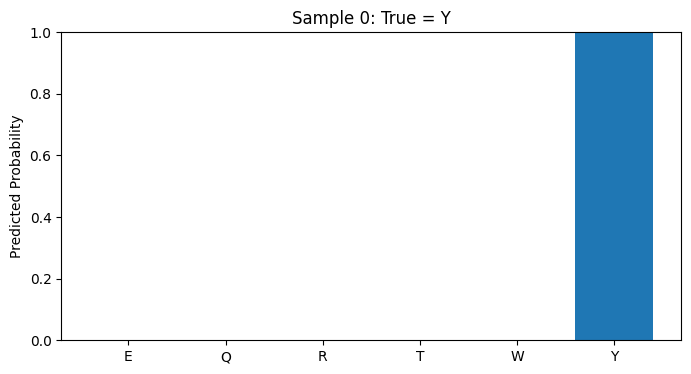

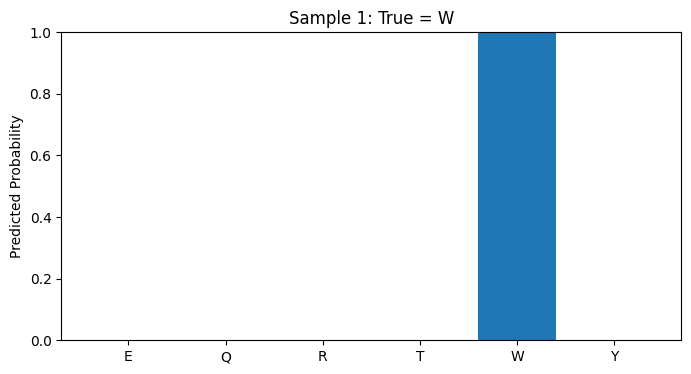

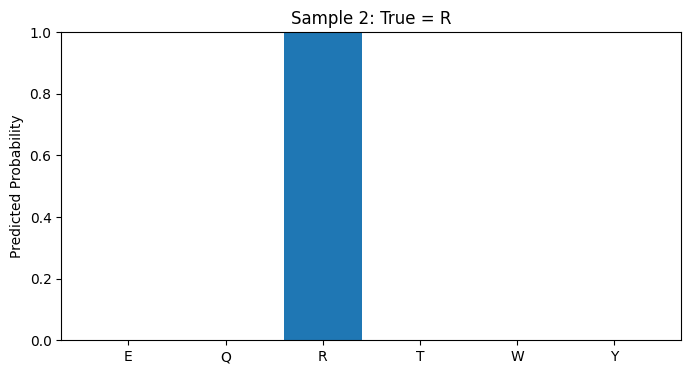

In [28]:
# --- Predict on test set ---
y_pred_keys = key_model.predict(Xk_test)
y_pred_classes = np.argmax(y_pred_keys, axis=1)
y_true_classes = np.argmax(yk_test, axis=1)

# --- Print sample predictions ---
for i in range(5):
    true_label = encoder.classes_[y_true_classes[i]]
    pred_label = encoder.classes_[y_pred_classes[i]]
    print(f"Sample {i}: Actual = {true_label}, Predicted = {pred_label}")


# --- Plot probability distributions for first 3 samples ---
for i in range(3):
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(encoder.classes_)), y_pred_keys[i])
    plt.xticks(range(len(encoder.classes_)), encoder.classes_)
    plt.title(f"Sample {i}: True = {encoder.classes_[y_true_classes[i]]}")
    plt.ylabel("Predicted Probability")
    plt.ylim(0, 1)  # optional: keeps the scale consistent
    plt.show()
